# Point operations


In [1]:
import imageio
import numpy as np
from matplotlib import pyplot as plt
import skimage

## Exercises

1. Show the histogram for the two modified images from the lab (`newim` and `newim2`).  (Copy the code for calculating `newim` and `newim2` here.)  Explain how the histogram shows visually how the colors have been transformed.  

*Note: put your text response in a text/Markdown cell, not in code comments.*

C:\tmp\ipykernel_12352\4260535259.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('love_and_peace.jpg')


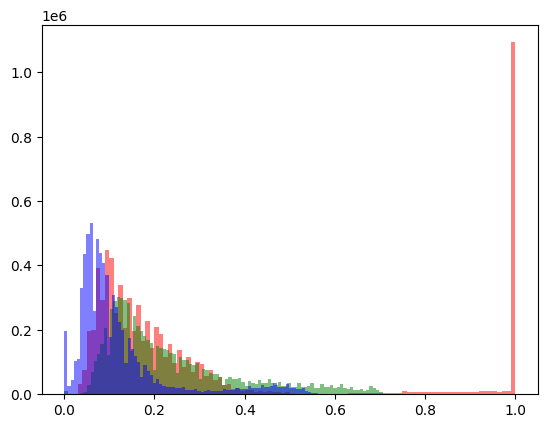

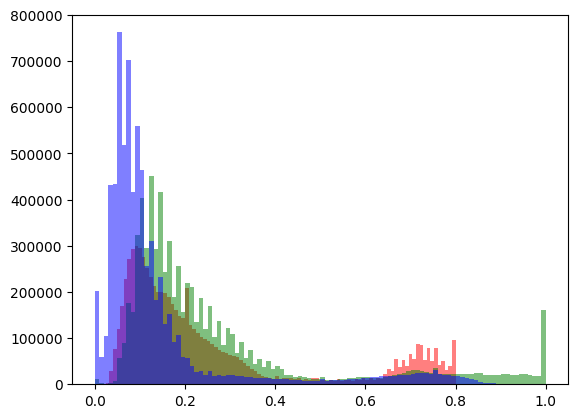

In [6]:
im = imageio.imread('love_and_peace.jpg')
im = im.astype('float32')/255
newim = im.copy()
newim[...,0] *= 1.25
newim[...,1] /= 1.25
newim[...,2] /= 1.25
newim = np.clip(newim,0,1)
mask = im[...,0]>0.5
newim = im.copy()
newim[mask,0] *= 1.25
newim[mask,1] /= 1.25
newim[mask,2] /= 1.25
newim = np.clip(newim,0,1)
newim2 = im.copy()
newim2[mask,0] /= 1.25
newim2[mask,1] *= 1.25
newim2[mask,2] *= 1.25
newim2 = np.clip(newim2,0,1)

channels = ['red','green','blue']
for i,channel in enumerate(channels):
    plt.hist(newim[:,:,i].flatten(),bins=100,color=channel,alpha=0.5)
plt.show()
for i,channel in enumerate(channels):
    plt.hist(newim2[:,:,i].flatten(),bins=100,color=channel,alpha=0.5)
plt.show()

We can see the increase of the red for newim at the very end with that huge spike, and for newim2, we can see the increase of the blue and green at the beginning.

2. Invert the image (compute one minus the image).  What does this do to the colors in the image?

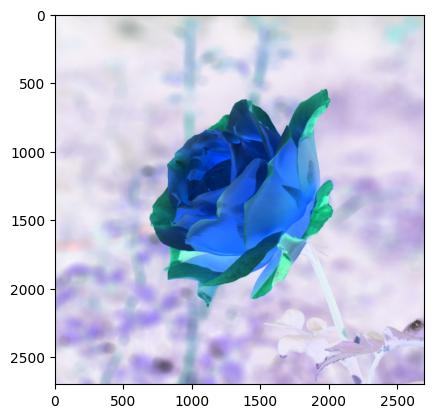

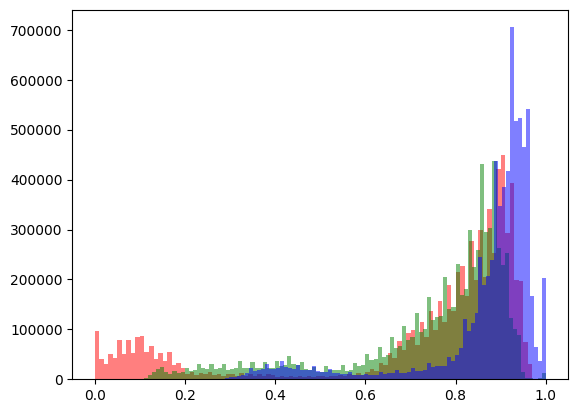

In [10]:
inverted = 1 - im
plt.imshow(inverted)
plt.show()
for i,channel in enumerate(channels):
    plt.hist(inverted[:,:,i].flatten(),bins=100,color=channel,alpha=0.5)
plt.show()

We can see all the colors movve to the opposite side of the spectrum, making the blues more apparent.

3. Load the "hand" image (`hand.jpg`) and show it.  Show the three color channels separately.

C:\tmp\ipykernel_12352\3774127347.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  hand = imageio.imread('hand.jpg')


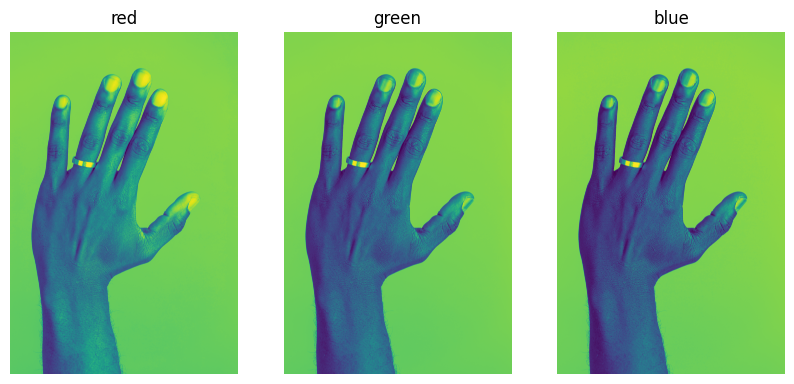

In [11]:
hand = imageio.imread('hand.jpg')
fig,axes = plt.subplots(1,3,figsize=(10,20))
for i,(ax,channel) in enumerate(zip(axes,channels)):
    ax.imshow(hand[...,i])
    ax.axis('off')
    ax.set_title(channel)

4. Now convert the image to the [Hue Saturation Value](https://en.wikipedia.org/wiki/HSL_and_HSV) colorspace (see [`skimage.color.rgb2hsv`](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_hsv.html)).    Show each channel of the HSV image.  



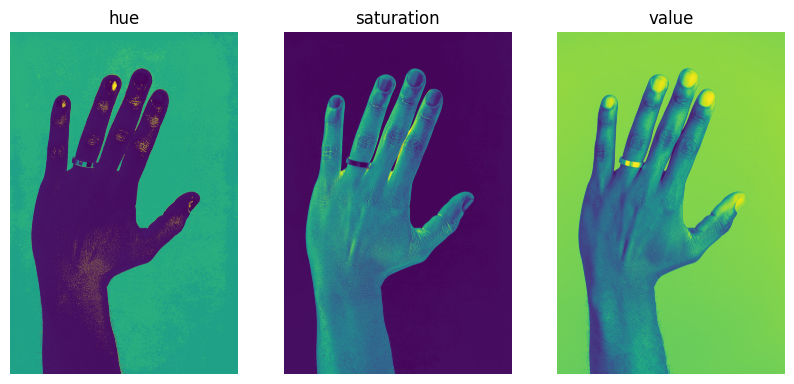

In [13]:
hsv_hand = skimage.color.rgb2hsv(hand)
fig,axes = plt.subplots(1,3,figsize=(10,20))
hsv = ['hue', 'saturation', 'value']
for i,(ax,h) in enumerate(zip(axes,hsv)):
    ax.imshow(hsv_hand[...,i])
    ax.axis('off')
    ax.set_title(h)


5. We want to separate the image into foreground (hand) and background using a threshold on one of the color channels.  All values greater than the threshold will be classified as foreground, and all othe values will be classified as background.

Would it be easier to separate this image into foreground and background using one of the RGB channels, or one of the HSV channels?

Look at the histogram for each channel to identify a good channel and threshold value for separating the image into foreground and background.  Apply the threshold and show the Boolean mask to evaluate the results.

#### Histograms

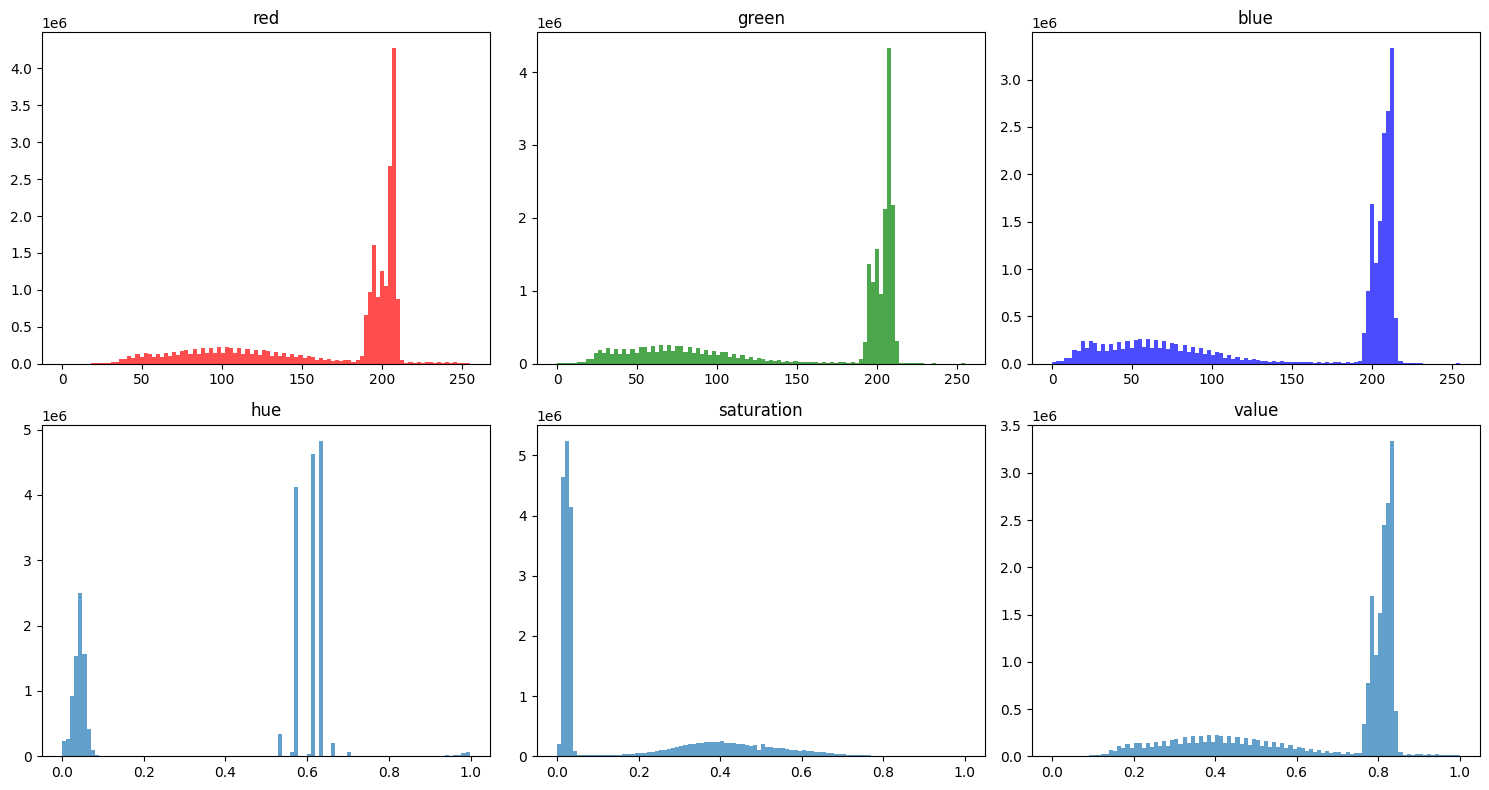

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, channel in enumerate(channels):
    axes[0, i].hist(hand[:,:,i].flatten(), bins=100, color=channel, alpha=0.7)
    axes[0, i].set_title(channel)
for i, h in enumerate(hsv):
    axes[1, i].hist(hsv_hand[:,:,i].flatten(), bins=100, alpha=0.7)
    axes[1, i].set_title(h)
plt.tight_layout()
plt.show()

#### Binary mask (it would be easier to do the binary mask on the saturation, as most of the values that are not the hand are clumped toward 0)

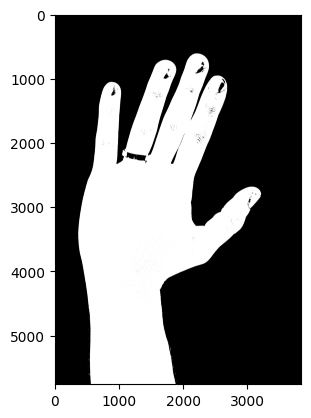

: 

In [ ]:
mask = hsv_hand[:,:, 1] > 0.1
plt.imshow(mask, cmap='gray')
plt.show()